In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import polars as pl
from preprocess_dataset_for_training import create_training_data
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# -------------------------------
# Reproducibility setup
# -------------------------------
seed = 42  # you can change this value
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # if using multi-GPU

# For deterministic behavior (slower but exact reproducibility)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# -------------------------------
# Device configuration
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# -------------------------------
# Load and preprocess data
# -------------------------------
file = "joined_df_with_weather"
joined_df = pl.read_parquet(f"./data/{file}.parquet")
X, y = create_training_data(joined_df)


Epoch [1/100], Train Loss: 0.580980, Val Loss: 1.001631
Epoch [2/100], Train Loss: 0.502672, Val Loss: 0.940304
Epoch [3/100], Train Loss: 0.466308, Val Loss: 0.918363
Epoch [4/100], Train Loss: 0.448828, Val Loss: 0.903902
Epoch [5/100], Train Loss: 0.436920, Val Loss: 0.896634
Epoch [6/100], Train Loss: 0.427261, Val Loss: 0.894608
Epoch [7/100], Train Loss: 0.419163, Val Loss: 0.895332
Epoch [8/100], Train Loss: 0.411910, Val Loss: 0.897893
Epoch [9/100], Train Loss: 0.405194, Val Loss: 0.903334
Epoch [10/100], Train Loss: 0.398934, Val Loss: 0.911520
Epoch [11/100], Train Loss: 0.392861, Val Loss: 0.919406
Early stopping triggered!
Target 1: MAE=39.8354, RMSE=70.0912, R2=0.4721
Target 2: MAE=39.7532, RMSE=69.8987, R2=0.4750
Target 3: MAE=11550.8828, RMSE=16768.8492, R2=0.6258
Target 4: MAE=46.1995, RMSE=82.2969, R2=0.2722
Target 5: MAE=45.5833, RMSE=82.4518, R2=0.2695
Target 6: MAE=13145.5166, RMSE=19502.1049, R2=0.4939
Target 7: MAE=48.9649, RMSE=87.3818, R2=0.1795
Target 8: MAE=4

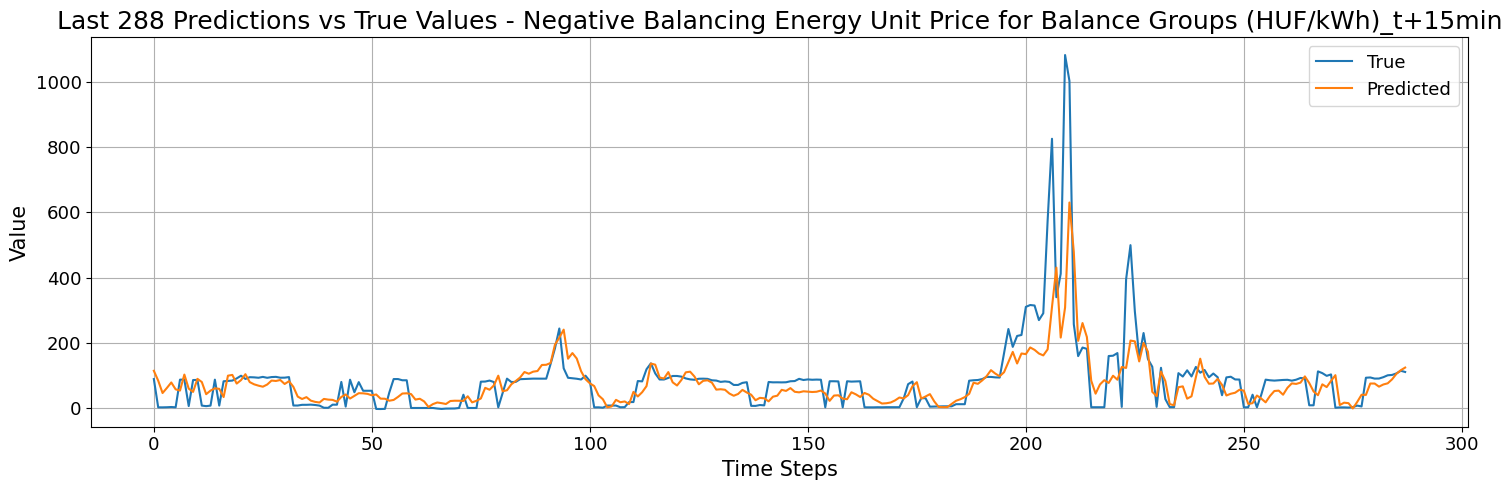

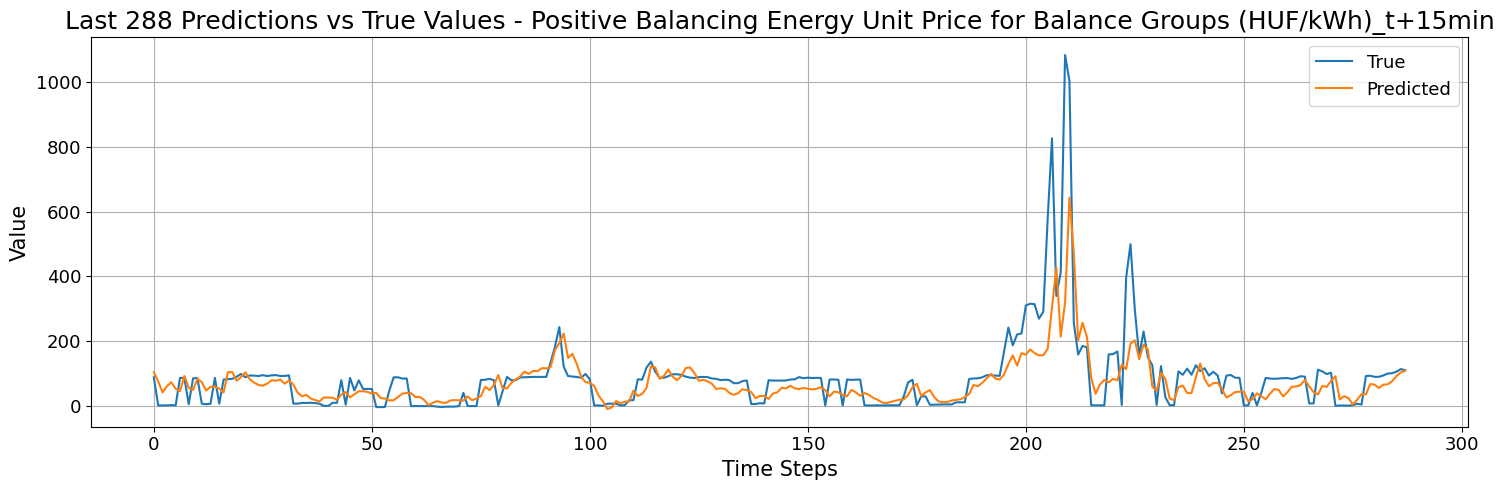

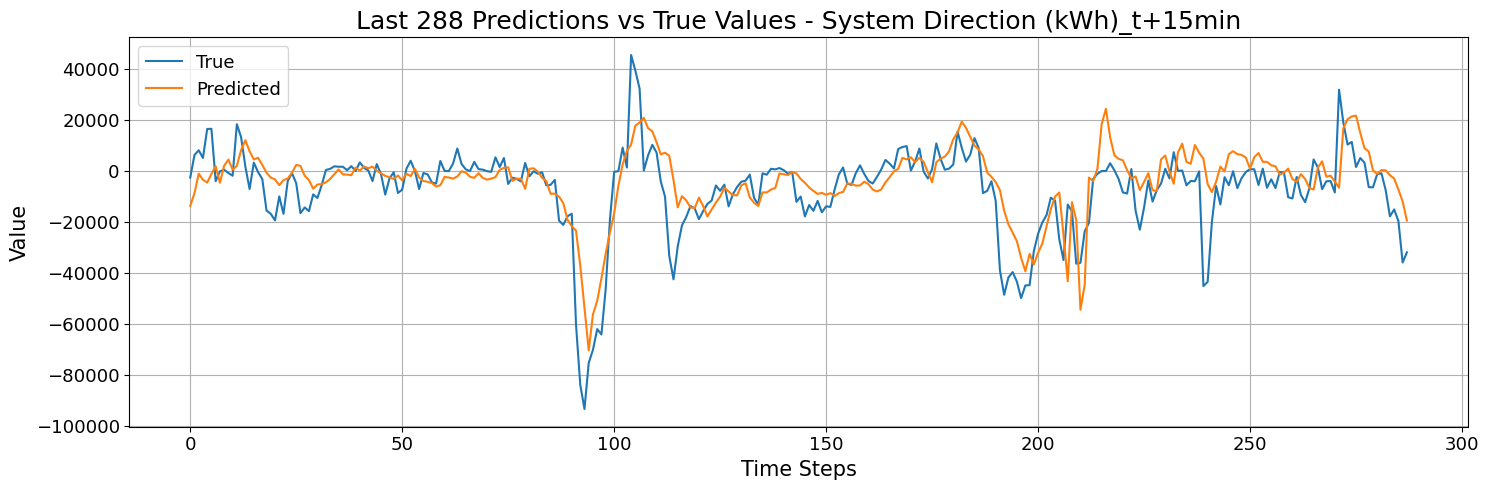

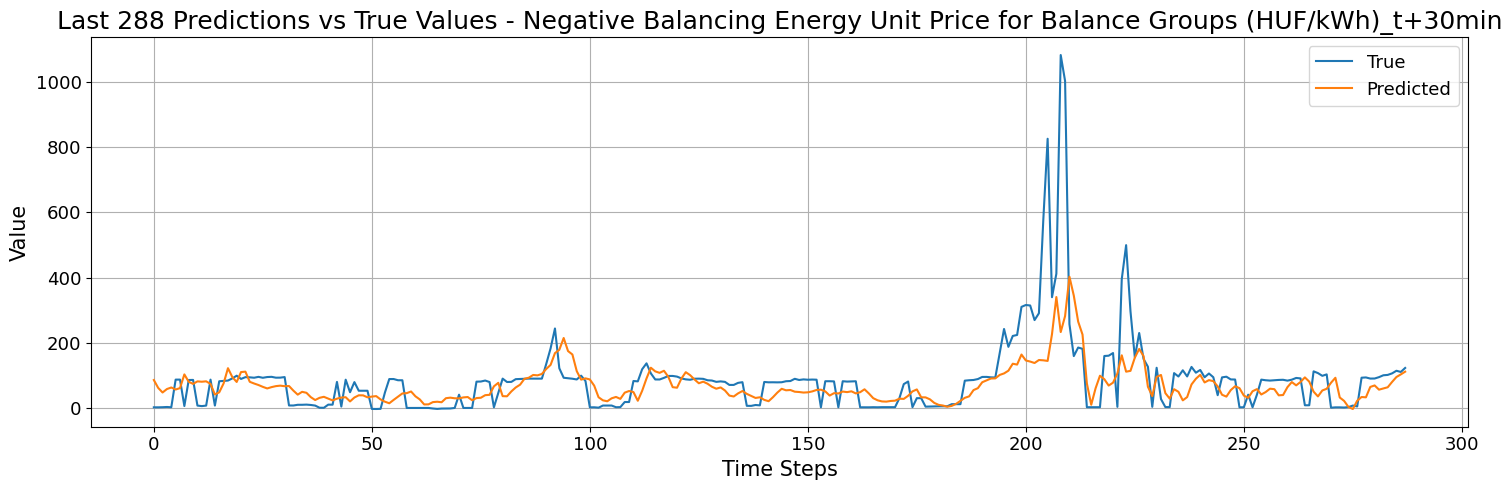

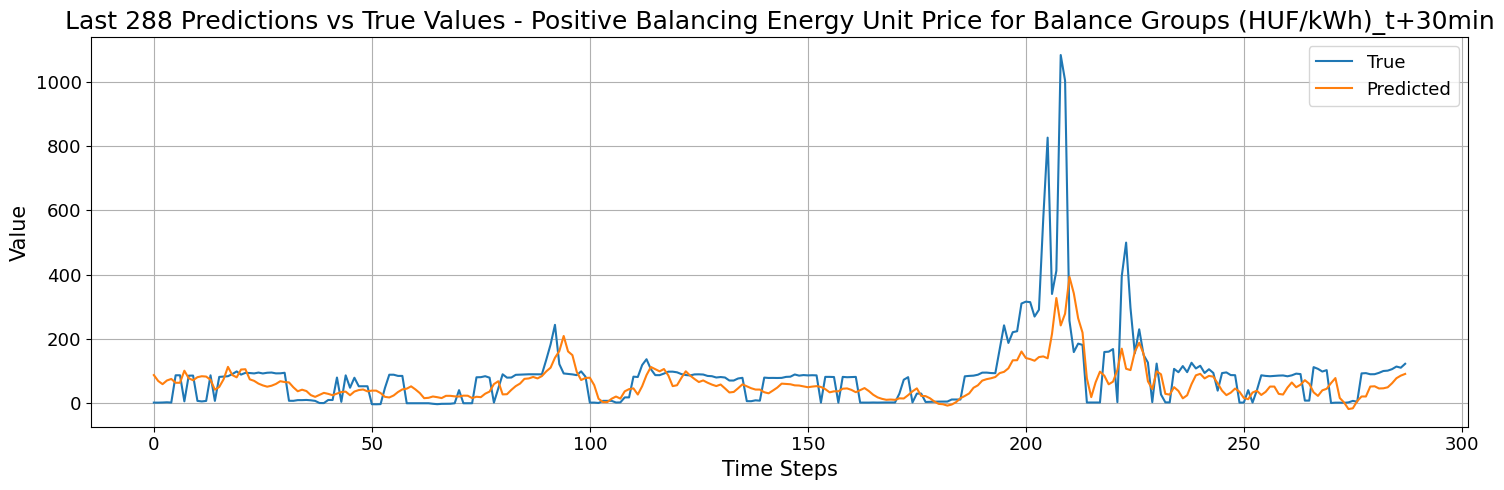

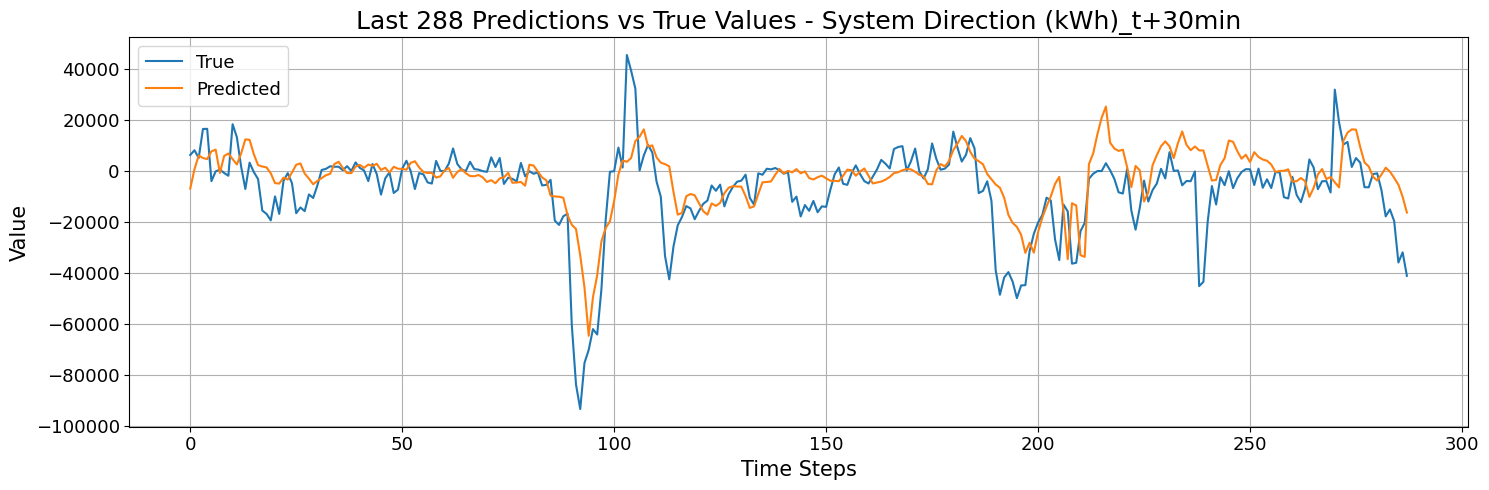

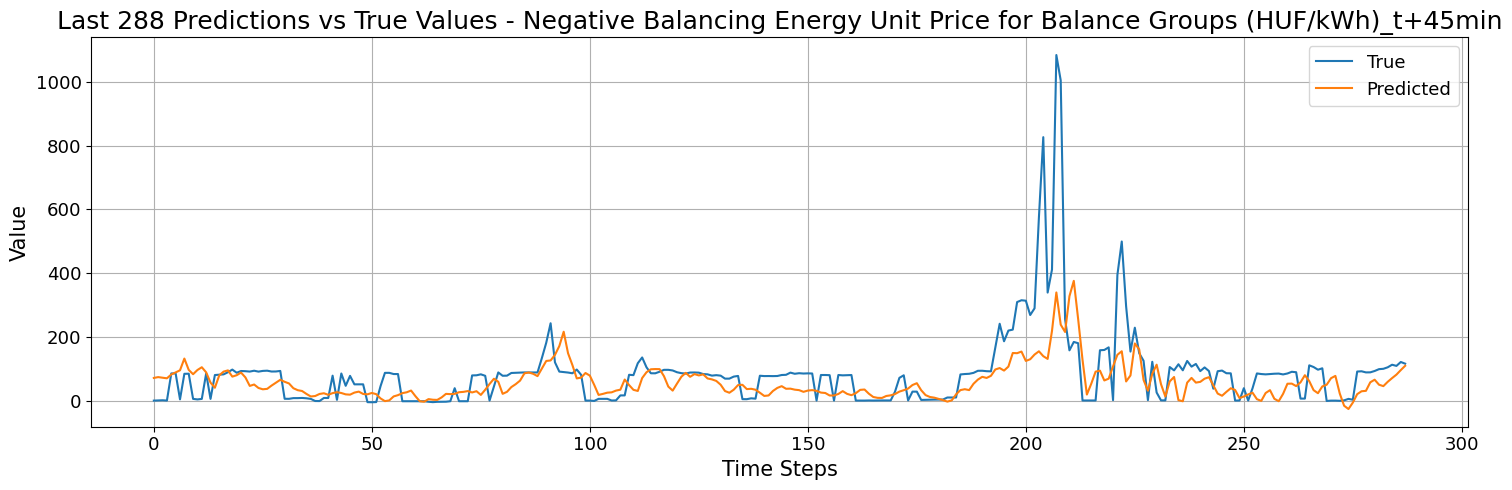

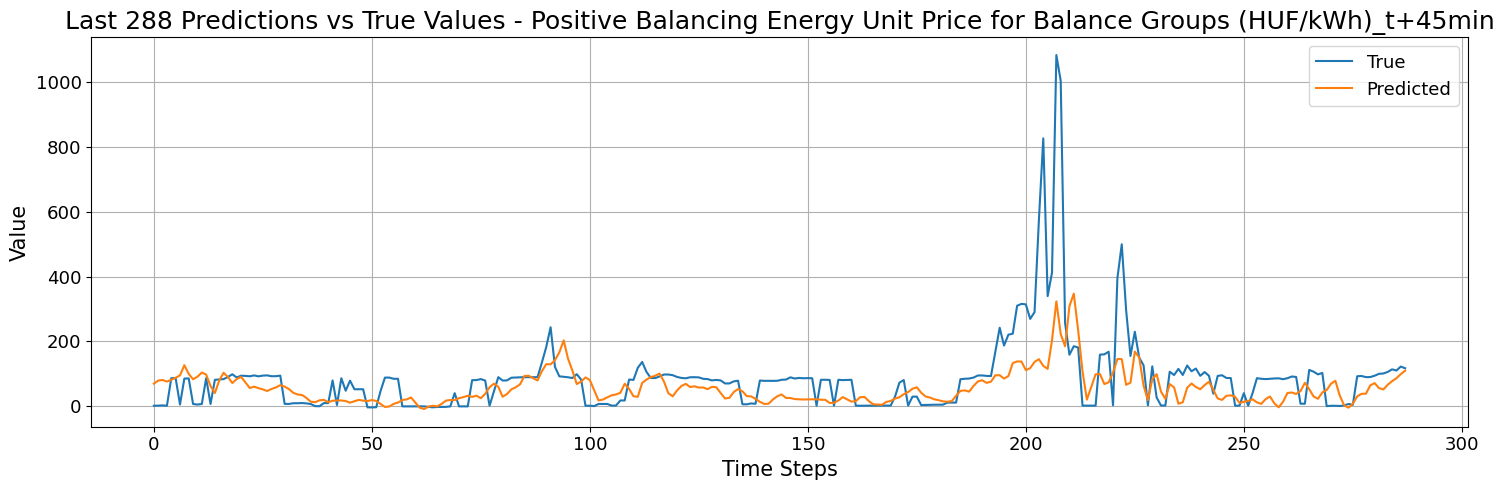

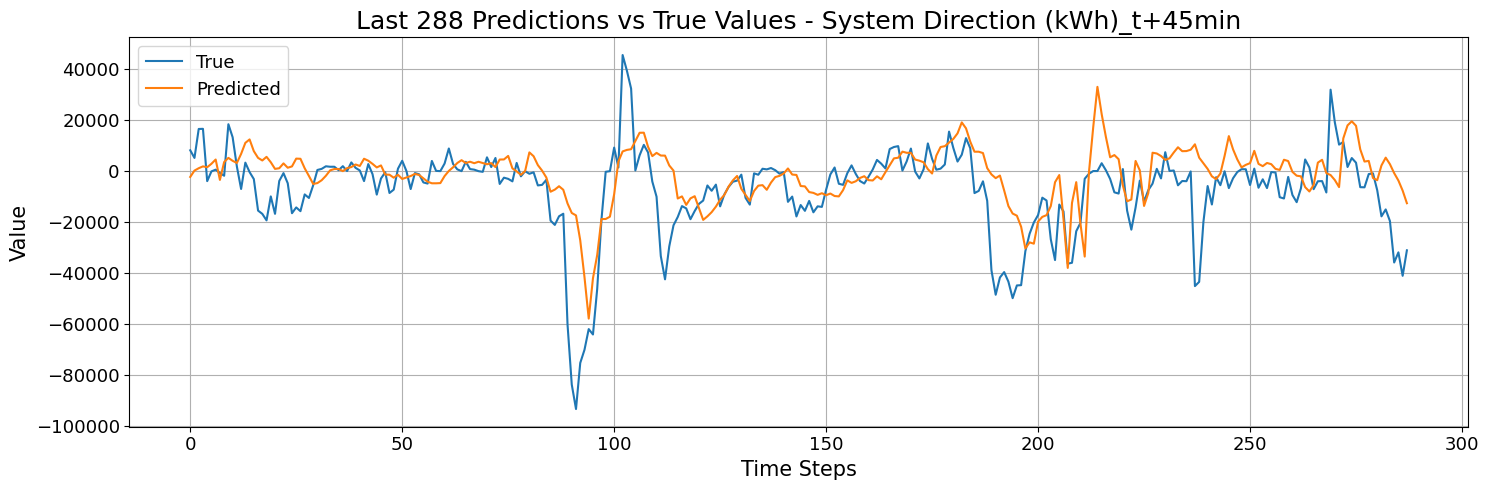

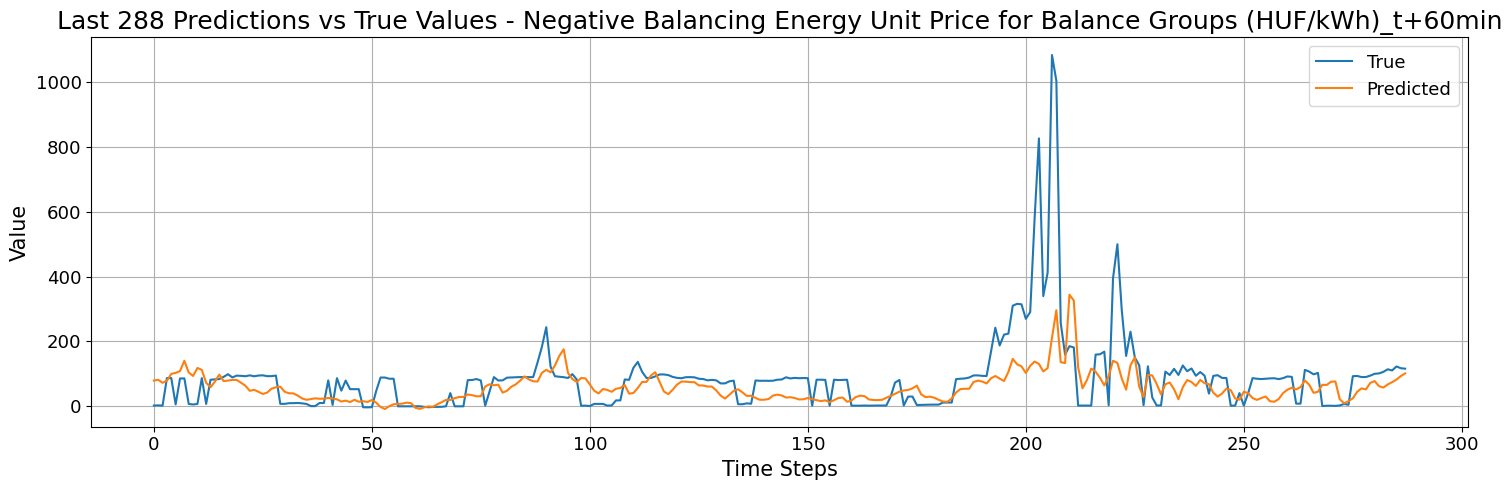

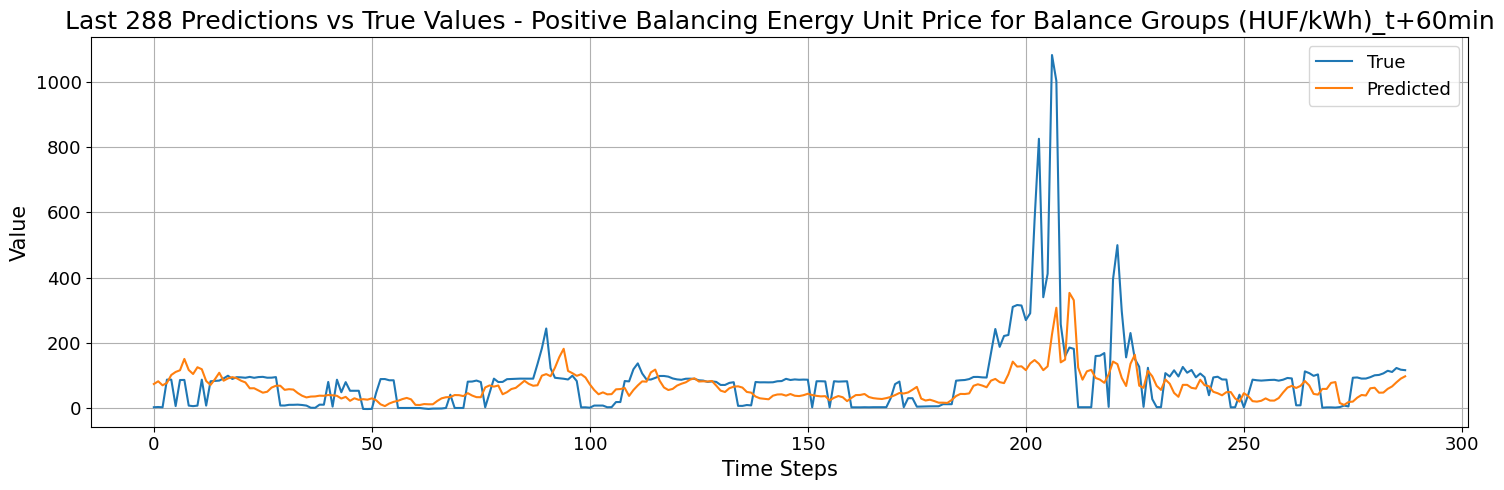

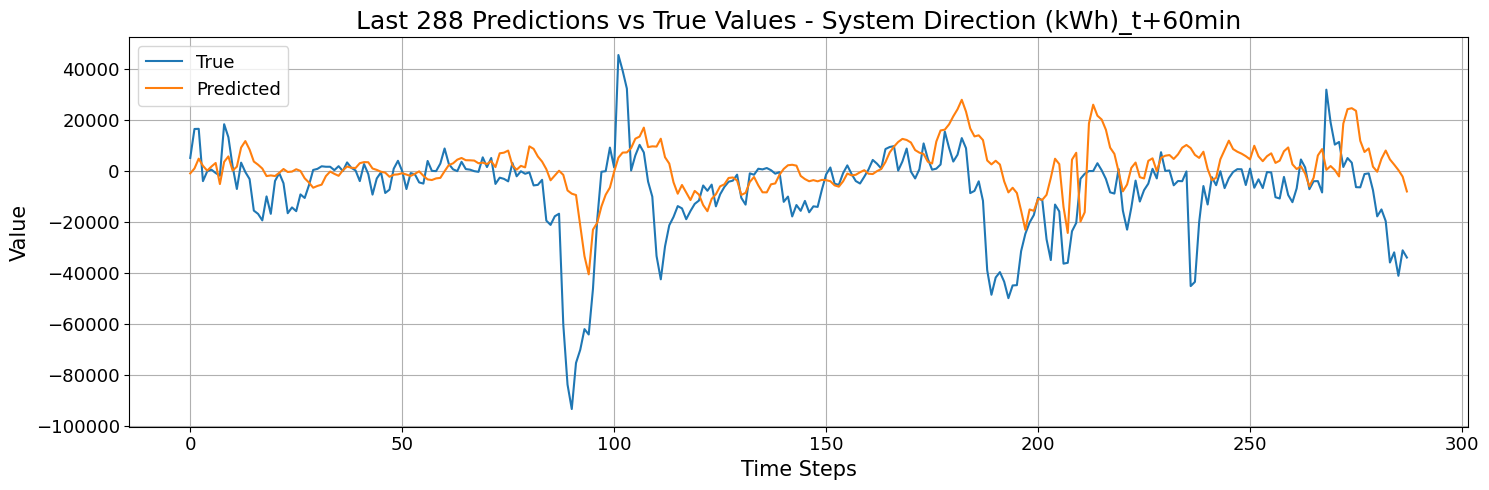

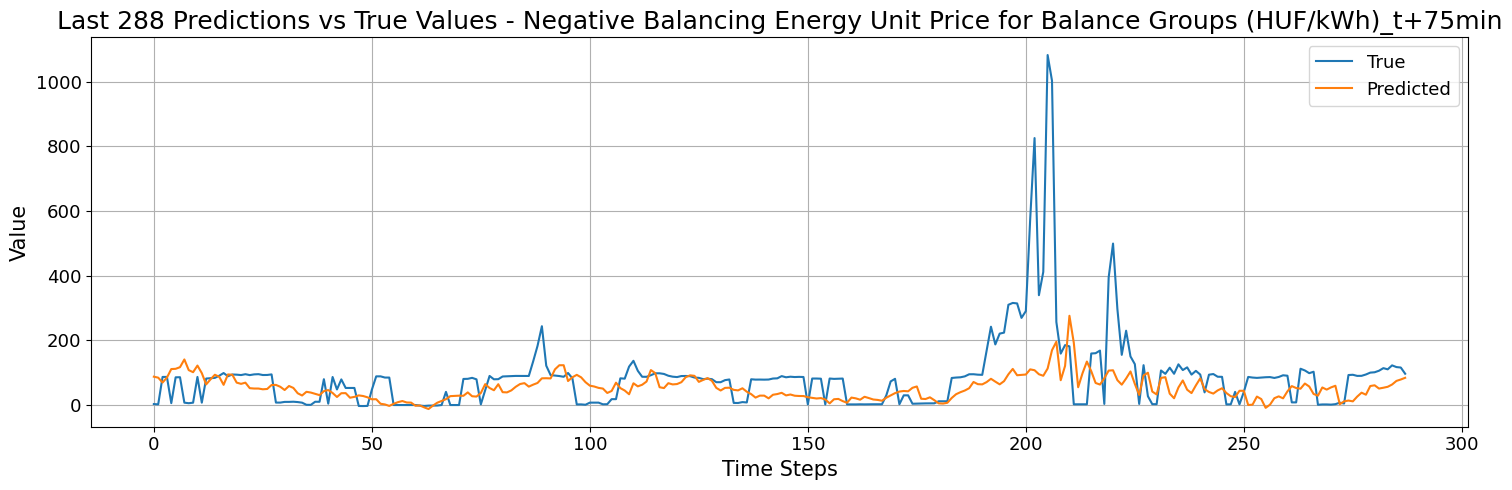

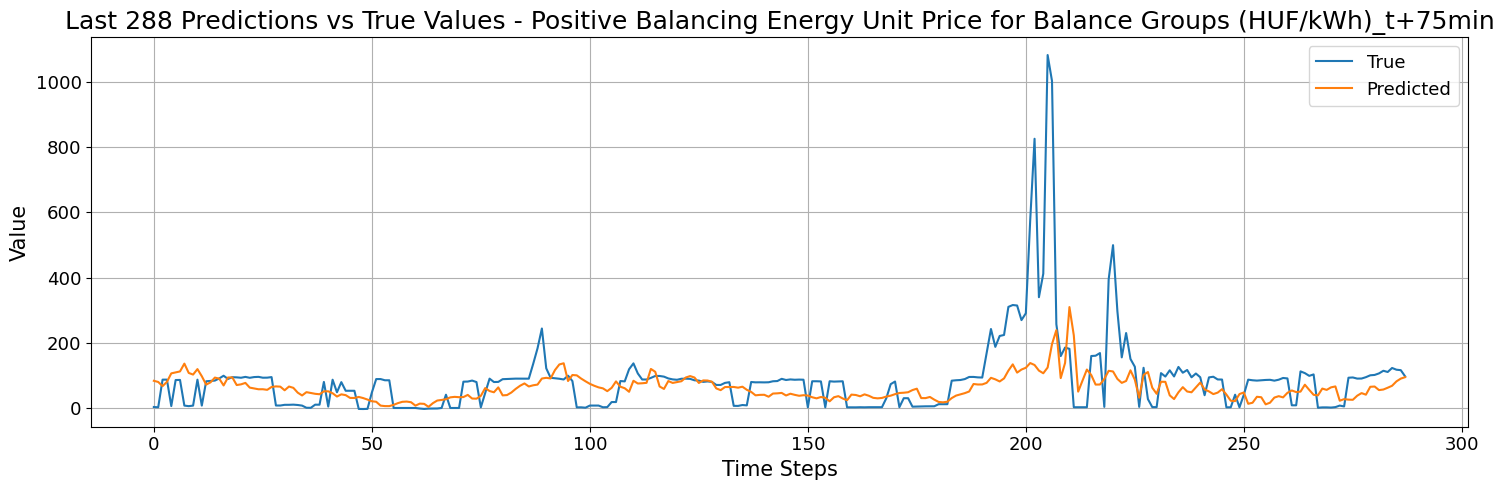

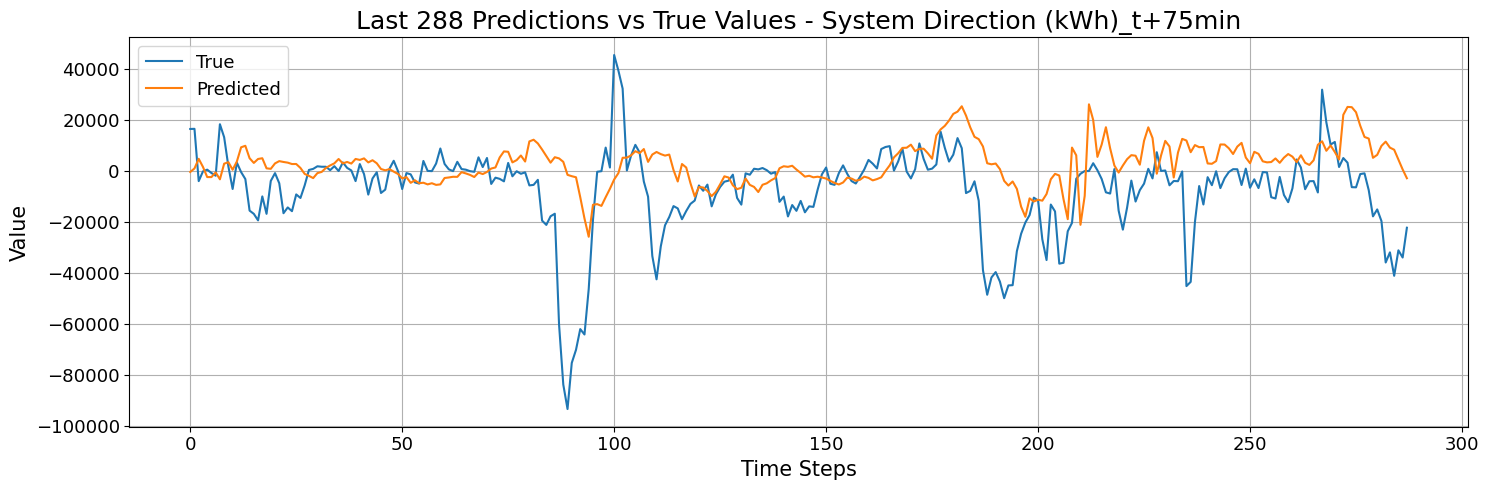

,Target,RMSE,MAE,R²
0,Negative Balancing Energy Unit Price for Balan...,70.091148,39.835419,0.472129
1,Positive Balancing Energy Unit Price for Balan...,69.898689,39.753155,0.475024
2,System Direction (kWh)_t+15min,16768.849609,11550.882812,0.625819
3,Negative Balancing Energy Unit Price for Balan...,82.296913,46.199528,0.272245
4,Positive Balancing Energy Unit Price for Balan...,82.451797,45.583286,0.269503
5,System Direction (kWh)_t+30min,19502.105469,13145.516602,0.493936
6,Negative Balancing Energy Unit Price for Balan...,87.381752,48.964909,0.179545
7,Positive Balancing Energy Unit Price for Balan...,86.925957,48.766510,0.188082
8,System Direction (kWh)_t+45min,20951.583984,13878.335938,0.415943
9,Negative Balancing Energy Unit Price for Balan...,88.800278,50.311359,0.152700


In [ ]:

X_np = X.to_numpy()
y_np = y.to_numpy()  # shape: (samples, 15 targets)
del joined_df, X
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_np, y_np, test_size=0.2, shuffle=False)
del X_np, y_np

# Feature scaling
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# Target scaling (important for stable float32 regression)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

# Convert to PyTorch tensors on CPU (we'll move batches to GPU)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
del X_train, X_test, y_train, y_test

# -------------------------------
# DataLoaders for batching
# -------------------------------
batch_size = 256  
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

test_dataset = TensorDataset(X_test_t, y_test_t)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# -------------------------------
# Define multi-output NN
# -------------------------------
class MultiOutputNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )

    def forward(self, x):
        return self.model(x)

input_dim = X_train_t.shape[1]
output_dim = y_train_t.shape[1]
model = MultiOutputNN(input_dim, output_dim).to(device)

# -------------------------------
# Loss and optimizer
# -------------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)  # smaller LR for stability

# -------------------------------
# Early stopping setup
# -------------------------------
best_val_loss = float('inf')
patience = 5
counter = 0

# -------------------------------
# Training loop (float32)
# -------------------------------
epochs = 100
for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    train_loss = running_loss / len(train_loader.dataset)
    
    # Validation loss
    model.eval()
    val_loss_total = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            outputs = model(X_batch)
            val_loss_total += criterion(outputs, y_batch).item() * X_batch.size(0)
    val_loss = val_loss_total / len(test_loader.dataset)
    
    print(f"Epoch [{epoch}/{epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

# -------------------------------
# Load best model
# -------------------------------
model.load_state_dict(torch.load("best_model.pt"))

# -------------------------------
# Evaluation
# -------------------------------
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        outputs = model(X_batch)
        y_pred_list.append(outputs.cpu())
        y_true_list.append(y_batch.cpu())

y_pred_scaled = torch.cat(y_pred_list).numpy()
y_true_scaled = torch.cat(y_true_list).numpy()

# Inverse-transform targets
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_true_scaled)


for i in range(output_dim):
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    print(f"Target {i+1}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")


# Evaluation
results = []
for idx, col in enumerate(y.columns):
    y_true_col = y_true[:, idx]
    y_pred_col = y_pred[:, idx]

    rmse = root_mean_squared_error(y_true_col, y_pred_col)
    mae = mean_absolute_error(y_true_col, y_pred_col)
    r2 = r2_score(y_true_col, y_pred_col)

    # Plotting last 288 predictions
    plt.figure(figsize=(15, 5))
    plt.plot(y_true_col[-288:], label="True")
    plt.plot(y_pred_col[-288:], label="Predicted")

    # Increased font sizes by 50%
    plt.title(f"Last 288 Predictions vs True Values - {col}", fontsize=18)
    plt.xlabel("Time Steps", fontsize=15)
    plt.ylabel("Value", fontsize=15)
    plt.legend(fontsize=13)
    plt.grid(True)

    # Increase tick label sizes
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)

    plt.tight_layout()
    plt.show()

    results.append({"Target": col, "RMSE": rmse, "MAE": mae, "R²": r2})

# Display metrics
results_df = pd.DataFrame(results)
display(results_df)


In [6]:
results_df.to_csv(f"evaluation_metrics_{file}.csv", index=False)